Read data from INTEGRATED HOUSEHOLD SURVEY 2019
https://microdata.worldbank.org/index.php/catalog/3818

In [1]:
import pandas as pd
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore

In [69]:
zipfile_path = '../data/IHS_survey/MWI_2019_IHS-V_v06_M_CSV.zip'


#open the zip file
with zipfile.ZipFile(zipfile_path, 'r') as z:
    #list the contents of the zip file
    #print(z.namelist())
    
    with z.open('HH_MOD_F.csv') as f: #electricity data
        #read the csv 
        df1 = pd.read_csv(f)
        
        print(df1.head(5))

    with z.open('householdgeovariables_ihs5.csv') as f: #geographic data
        #read the csv 
        df2 = pd.read_csv(f)
        
        print(df2.head(5))

    with z.open('HH_MOD_L.csv') as f: #goods
        #read the csv 
        df3 = pd.read_csv(f)
        
        print(df3.head(5))
    with z.open('hh_mod_a_filt.csv') as f: #geographic data  urban/rural
        #read the csv 
        df4 = pd.read_csv(f)
        
        print(df4.head(5))
   
    with z.open('HH_MOD_B.csv') as f: #household members
        #read the csv 
        df5 = pd.read_csv(f)
        
        print(df5.head(5))

        case_id                              HHID            hh_f01  \
0  101011000014  7d78f2c5da59436d9bde9b09ea8a8aaf             OWNED   
1  101011000023  7144cc6d29b3485d9e6d6188b255c756             OWNED   
2  101011000040  9936d103bf974a93afbc63d477b8b3f2  FREE, AUTHORIZED   
3  101011000071  cc8f211413cd493e83e01a96aba95bbb             OWNED   
4  101011000095  e50cfa8d11b44d56891e0fad015b07c7             OWNED   

   hh_f01_1a  hh_f01_1b  hh_f01_1b__0  hh_f01_1b__1  hh_f01_1c  hh_f01_1d  \
0        1.0        NaN           NaN           NaN        NaN        NaN   
1        1.0        NaN           NaN           NaN        NaN        NaN   
2        NaN        NaN           NaN           NaN        NaN        NaN   
3        2.0        NaN           NaN           NaN        NaN        NaN   
4        1.0        NaN           NaN           NaN        NaN        NaN   

  hh_f01_1filter  ... hh_f50 hh_f51a hh_f51b  hh_f51c  hh_f52 hh_f53 hh_f54  \
0             NO  ...     NO   

C:\Users\rheredia\AppData\Local\Temp\ipykernel_5852\3349583945.py:34: DtypeWarning: Columns (17,25,35,37,40,50) have mixed types. Specify dtype option on import or set low_memory=False.
  df5 = pd.read_csv(f)


In [61]:
df3

,case_id,HHID,hh_l01,hh_l02,hh_l03,hh_l04,hh_l05,hh_l06,hh_l07
0,101011000014,7d78f2c5da59436d9bde9b09ea8a8aaf,No,Mortar/pestle (mtondo),NaN,NaN,NaN,NaN,NaN
1,101011000014,7d78f2c5da59436d9bde9b09ea8a8aaf,Yes,Bed,1.0,2.0,15000.0,NO,NaN
2,101011000014,7d78f2c5da59436d9bde9b09ea8a8aaf,Yes,Table,1.0,10.0,5000.0,NO,NaN
3,101011000014,7d78f2c5da59436d9bde9b09ea8a8aaf,Yes,Chair,3.0,10.0,3000.0,NO,NaN
4,101011000014,7d78f2c5da59436d9bde9b09ea8a8aaf,No,Fan,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
388751,315538160239,de477d97327c42a3804781971d0b90cf,No,Sattelite dish,NaN,NaN,NaN,NaN,NaN
388752,315538160239,de477d97327c42a3804781971d0b90cf,No,Solar panel,NaN,NaN,NaN,NaN,NaN
388753,315538160239,de477d97327c42a3804781971d0b90cf,No,Generator,NaN,NaN,NaN,NaN,NaN
388754,315538160239,de477d97327c42a3804781971d0b90cf,No,Electric Kettle,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Appliance ownership data#

# columns
df_ap = df3[['case_id', 'hh_l02', 'hh_l03']]
# the ones having electricity
#df_ap = df_ap[df_ap['hh_l01']=='Yes']

# filtering electric appliances #no VCR
elec_list = ['Fan', 'Television', 'Air conditioner', 'Tape or CD/DVD player; HiFi',
             'VCR', 'Refrigerator', 'Washing machine'] #'Sewing machine'
df_ap = df_ap[(df_ap['hh_l02'].isin(elec_list)) | (df_ap['hh_l02'].str.startswith('Radio')) |
          (df_ap['hh_l02'].str.startswith('Tape')) | (df_ap['hh_l02'].str.startswith('Electric'))]

# update all Radio
df_ap.loc[df_ap['hh_l02'].str.startswith('Radio'), 'hh_l02'] = 'Radio'

# update the appliance names
update_name = {'Tape or CD/DVD player; HiFi' : 'Radio',
               'VCR' : 'Radio',
               'Fan': 'Air circulation',
               'Electric or gas stove; hot plate' : 'Air conditioner', # ~wattage of 1500w for electic stove and AC
               'Electric Kettle' : 'Iron', # ~wattage of 1200w for electic kettle and iron
            
               }
df_ap['hh_l02'] = df_ap['hh_l02'].replace(update_name)
df_ap = df_ap.groupby(['case_id','hh_l02'])['hh_l03'].sum().reset_index()
df_ap

,case_id,hh_l02,hh_l03
0,101011000014,Air circulation,0.0
1,101011000014,Air conditioner,0.0
2,101011000014,Iron,0.0
3,101011000014,Radio,0.0
4,101011000014,Refrigerator,0.0
...,...,...,...
80033,315538160239,Iron,0.0
80034,315538160239,Radio,0.0
80035,315538160239,Refrigerator,0.0
80036,315538160239,Television,0.0


In [ ]:
# hh_f19 discrete answer yes or no to electricity
df1[['case_id', 'hh_f19']]

,case_id,hh_f19
0,101011000014,NO
1,101011000023,NO
2,101011000040,NO
3,101011000071,NO
4,101011000095,NO
...,...,...
11429,315538160177,NO
11430,315538160189,YES
11431,315538160190,YES
11432,315538160235,YES


In [76]:
# pivot table
df_ap_filter = pd.pivot_table(df_ap, index=['case_id'], columns='hh_l02', values='hh_l03', aggfunc='sum').reset_index().fillna(0)
df_ap_filter = pd.merge(df_ap_filter, df1[['case_id', 'hh_f19']], on='case_id', how='left')
df_ap_filter = df_ap_filter.rename(columns={'hh_f19':'Electricity'})
df_ap_filter['Electricity'] = df_ap_filter['Electricity'].replace({'NO':0, 'YES':1})
df_ap_filter

C:\Users\rheredia\AppData\Local\Temp\ipykernel_5852\3430700509.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_ap_filter['Electricity'] = df_ap_filter['Electricity'].replace({'NO':0, 'YES':1})


,case_id,Air circulation,Air conditioner,Iron,Radio,Refrigerator,Television,Washing machine,Electricity
0,101011000014,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,101011000023,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,101011000040,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
3,101011000071,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
4,101011000095,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...
11429,315538160177,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
11430,315538160189,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1
11431,315538160190,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1
11432,315538160235,1.0,0.0,0.0,3.0,0.0,1.0,0.0,1


In [77]:
df_ap['hh_l02'].unique()

array(['Air circulation', 'Air conditioner', 'Iron', 'Radio',
       'Refrigerator', 'Television', 'Washing machine'], dtype=object)

In [78]:
# df1, df2 subset
df1_subset = df1[['case_id', 'hh_f11', 'hh_f11_oth', 'hh_f12', 'hh_f19', 'hh_f25', 'hh_f26a', 'hh_f26b']]
df2_subset = df2[['case_id', 'ea_lat_mod' , 'ea_lon_mod']]
df4_subset = df4[['case_id', 'region', 'reside', 'hh_wgt']]

#cases with electric appliances
case_id_elec = df_ap['case_id'].unique()
case_id_elec
# Filter only cases with electric appliances
subsets = [df1_subset, df2_subset, df4_subset]
for i in range(len(subsets)):
    subsets[i] = subsets[i][subsets[i]['case_id'].isin(case_id_elec)]

# Assign the filtered DataFrames back to their respective variables
df1_subset, df2_subset, df4_subset = subsets

In [79]:
# household with access to electricity
#hh_elec = df_ap['case_id'].unique().tolist()

# grouping by case_id and summing the members in household
nhh = df5.groupby('case_id').size().reset_index(name='Number of household members')
# filtering the household members
#nhh = nhh[nhh['case_id'].isin(hh_elec)]
nhh

,case_id,Number of household members
0,101011000014,4
1,101011000023,4
2,101011000040,4
3,101011000071,5
4,101011000095,5
...,...,...
11429,315538160177,3
11430,315538160189,3
11431,315538160190,1
11432,315538160235,3


In [80]:
df_merged = pd.merge(df1_subset, df2_subset, on='case_id', how='left')
df_merged = pd.merge(df_merged, df_ap_filter, on='case_id', how='left')
df_merged = pd.merge(df_merged, df4_subset, on='case_id', how='left')
df_merged = pd.merge(df_merged, nhh, on='case_id', how='left')
df_merged

,case_id,hh_f11,hh_f11_oth,hh_f12,hh_f19,hh_f25,hh_f26a,hh_f26b,ea_lat_mod,ea_lon_mod,...,Iron,Radio,Refrigerator,Television,Washing machine,Electricity,region,reside,hh_wgt,Number of household members
0,101011000014,BATTERY/DRY CELL(TORCH),NaN,COLLECTED FIREWOOD,NO,NaN,NaN,NaN,-9.70057,33.239170,...,0.0,0.0,0.0,0.0,0.0,0,North,RURAL,93.719400,4
1,101011000023,BATTERY/DRY CELL(TORCH),NaN,COLLECTED FIREWOOD,NO,NaN,NaN,NaN,-9.70057,33.239170,...,0.0,0.0,0.0,0.0,0.0,0,North,RURAL,93.719400,4
2,101011000040,BATTERY/DRY CELL(TORCH),NaN,COLLECTED FIREWOOD,NO,NaN,NaN,NaN,-9.70057,33.239170,...,0.0,1.0,0.0,0.0,0.0,0,North,RURAL,93.719400,4
3,101011000071,BATTERY/DRY CELL(TORCH),NaN,COLLECTED FIREWOOD,NO,NaN,NaN,NaN,-9.70057,33.239170,...,0.0,1.0,0.0,0.0,0.0,0,North,RURAL,93.719400,5
4,101011000095,BATTERY/DRY CELL(TORCH),NaN,COLLECTED FIREWOOD,NO,NaN,NaN,NaN,-9.70057,33.239170,...,0.0,0.0,0.0,0.0,0.0,0,North,RURAL,93.719400,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11429,315538160177,OTHER(SPECIFY),SOLAR,CHARCOAL,NO,NaN,NaN,NaN,-15.83674,35.036121,...,0.0,1.0,0.0,0.0,0.0,0,Southern,URBAN,607.988356,3
11430,315538160189,ELECTRICITY,NaN,CHARCOAL,YES,5000.0,1.0,MONTH,-15.83674,35.036121,...,0.0,1.0,0.0,1.0,0.0,1,Southern,URBAN,607.988356,3
11431,315538160190,ELECTRICITY,NaN,CHARCOAL,YES,NaN,NaN,NaN,-15.83674,35.036121,...,1.0,1.0,1.0,1.0,0.0,1,Southern,URBAN,607.988356,1
11432,315538160235,ELECTRICITY,NaN,CHARCOAL,YES,4000.0,1.0,MONTH,-15.83674,35.036121,...,0.0,3.0,0.0,1.0,0.0,1,Southern,URBAN,607.988356,3


In [124]:
#df_merged.to_csv('data/household_data.csv', index=False)

# PCA for RWI

Principal component analysis to generate rwi

In [81]:
#data frame with goods
df_goods = df3[['case_id', 'hh_l01', 'hh_l02']]
df_goods.replace({'hh_l01': {'Yes': 1, 'No': 0}}, inplace=True)
#df_goods = df_goods[df_goods['case_id'].isin(case_id_elec)]

# goods list
goods_list = df_goods['hh_l02'].unique().tolist()

df_goods = pd.pivot_table(df_goods, index='case_id', columns='hh_l02', values='hh_l01', aggfunc='sum').reset_index().fillna(0)
#df_goods = df_goods[df_goods['case_id'].isin(case_id_elec)]
df_goods

C:\Users\rheredia\AppData\Local\Temp\ipykernel_5852\348333369.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_goods.replace({'hh_l01': {'Yes': 1, 'No': 0}}, inplace=True)
C:\Users\rheredia\AppData\Local\Temp\ipykernel_5852\348333369.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_goods.replace({'hh_l01': {'Yes': 1, 'No': 0}}, inplace=True)


hh_l02,case_id,Air conditioner,Bed,Beer-brewing drum,Bicycle,Car,Chair,Clock,Coffee table (for sitting room),Computer equipment & accessories,...,Refrigerator,Sattelite dish,Sewing machine,Solar panel,Table,Tape or CD/DVD player; HiFi,Television,"Upholstered chair, sofa set",VCR,Washing machine
0,101011000014,0,1,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,101011000023,0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,101011000040,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,101011000071,0,1,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
4,101011000095,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11429,315538160177,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
11430,315538160189,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,0,0,0
11431,315538160190,0,1,0,0,0,1,0,1,0,...,1,0,0,0,0,1,1,1,0,0
11432,315538160235,0,1,0,0,0,0,1,0,0,...,0,0,0,0,1,1,1,0,0,0


In [82]:
goods_list

['Mortar/pestle (mtondo)',
 'Bed',
 'Table',
 'Chair',
 'Fan',
 'Air conditioner',
 "Radio ('wireless')",
 'Tape or CD/DVD player; HiFi',
 'Television',
 'VCR',
 'Sewing machine',
 'Kerosene/paraffin stove',
 'Electric or gas stove; hot plate',
 'Refrigerator',
 'Washing machine',
 'Bicycle',
 'Motorcycle / Scooter',
 'Car',
 'Mini-bus',
 'Lorry',
 'Beer-brewing drum',
 'Upholstered chair, sofa set',
 'Coffee table (for sitting room)',
 'Cupboard, drawers, bureau',
 'Lantern (paraffin)',
 'Desk',
 'Clock',
 'Iron (for pressing clothes)',
 'Computer equipment & accessories',
 'Sattelite dish',
 'Solar panel',
 'Generator',
 'Electric Kettle',
 'Radio with flash drive/micro CD']

In [83]:
# area
df4_subset

,case_id,region,reside,hh_wgt
0,101011000014,North,RURAL,93.719400
1,101011000023,North,RURAL,93.719400
2,101011000040,North,RURAL,93.719400
3,101011000071,North,RURAL,93.719400
4,101011000095,North,RURAL,93.719400
...,...,...,...,...
11429,315538160177,Southern,URBAN,607.988356
11430,315538160189,Southern,URBAN,607.988356
11431,315538160190,Southern,URBAN,607.988356
11432,315538160235,Southern,URBAN,607.988356


In [84]:
# fuel for cooking
df_fuel = df1_subset[['case_id', 'hh_f12']]
df_fuel.rename(columns={'hh_f12': 'cooking_fuel'}, inplace=True)
df_fuel

C:\Users\rheredia\AppData\Local\Temp\ipykernel_5852\3660289738.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fuel.rename(columns={'hh_f12': 'cooking_fuel'}, inplace=True)


,case_id,cooking_fuel
0,101011000014,COLLECTED FIREWOOD
1,101011000023,COLLECTED FIREWOOD
2,101011000040,COLLECTED FIREWOOD
3,101011000071,COLLECTED FIREWOOD
4,101011000095,COLLECTED FIREWOOD
...,...,...
11429,315538160177,CHARCOAL
11430,315538160189,CHARCOAL
11431,315538160190,CHARCOAL
11432,315538160235,CHARCOAL


In [85]:
# df with appliances and cooking fuel
df_pc = pd.merge(df_goods, df_fuel, on='case_id', how='left')
df_pc = pd.merge(df_pc, df4_subset, on='case_id', how='left')
df_pc['reside'] = df_pc['reside'].str.lower()
# Replace urban and rural with 1 and 2
df_pc['Type of place of residence'] = df_pc['reside'].replace({'urban':1, 'rural':2})

df_pc

C:\Users\rheredia\AppData\Local\Temp\ipykernel_5852\13384179.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_pc['Type of place of residence'] = df_pc['reside'].replace({'urban':1, 'rural':2})


,case_id,Air conditioner,Bed,Beer-brewing drum,Bicycle,Car,Chair,Clock,Coffee table (for sitting room),Computer equipment & accessories,...,Tape or CD/DVD player; HiFi,Television,"Upholstered chair, sofa set",VCR,Washing machine,cooking_fuel,region,reside,hh_wgt,Type of place of residence
0,101011000014,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,COLLECTED FIREWOOD,North,rural,93.719400,2
1,101011000023,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,COLLECTED FIREWOOD,North,rural,93.719400,2
2,101011000040,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,COLLECTED FIREWOOD,North,rural,93.719400,2
3,101011000071,0,1,0,1,0,0,0,1,0,...,0,0,1,0,0,COLLECTED FIREWOOD,North,rural,93.719400,2
4,101011000095,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,COLLECTED FIREWOOD,North,rural,93.719400,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11429,315538160177,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,CHARCOAL,Southern,urban,607.988356,1
11430,315538160189,0,0,0,0,0,0,0,0,0,...,1,1,0,0,0,CHARCOAL,Southern,urban,607.988356,1
11431,315538160190,0,1,0,0,0,1,0,1,0,...,1,1,1,0,0,CHARCOAL,Southern,urban,607.988356,1
11432,315538160235,0,1,0,0,0,0,1,0,0,...,1,1,0,0,0,CHARCOAL,Southern,urban,607.988356,1


## PCA

- generate a principal component (1sr component). This is the rwi.
- remove the outliers generating wide distribution of rwi.

In [92]:
def calculate_wealth_index_extended(df, binary_vars, categorical_vars, urban_rural_col):
    results = []

    for group in df[urban_rural_col].unique():
        subset = df[df[urban_rural_col] == group].copy()

        # One-hot encode categorical variables
        one_hot = pd.get_dummies(subset[categorical_vars], drop_first=True)

        # Combine with binary variables
        X = pd.concat([subset[binary_vars], one_hot], axis=1)

        # Standardize the data
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # Calculate z-scores for each feature (across all rows)
        z_scores = np.abs(zscore(X_scaled))  # Take absolute value to catch both positive and negative outliers

        # Set a threshold for identifying outliers
        threshold = 3  # Anything beyond 3 standard deviations is considered an outlier

        # Find rows where any feature has a z-score greater than the threshold
        outliers = (z_scores > threshold).any(axis=1)

        # Remove rows with outliers
        df_cleaned = subset[~outliers].copy()  # Only apply outlier removal to the subset

        # One-hot encode the categorical variables for the cleaned subset
        one_hot_cleaned = pd.get_dummies(df_cleaned[categorical_vars], drop_first=True)

        # Combine with binary variables for the cleaned data
        X_cleaned = pd.concat([df_cleaned[binary_vars], one_hot_cleaned], axis=1)

        # Standardize the cleaned data
        X_scaled_cleaned = scaler.fit_transform(X_cleaned)

        # Create a DataFrame with scaled features for visualization
        scaled_df = pd.DataFrame(X_scaled_cleaned, columns=X_cleaned.columns)

        # Plot boxplots for each feature
        plt.figure(figsize=(12, 8))
        sns.boxplot(data=scaled_df, orient='h')
        plt.title("Boxplot of Scaled Features to Check for Outliers")
        plt.show()

        # PCA - First component is wealth index
        pca = PCA(n_components=1)
        pca_score = pca.fit_transform(X_scaled_cleaned).flatten()

        # Check the explained variance ratio
        print("Explained variance ratio of the first component:", pca.explained_variance_ratio_)

        # Store wealth index in the cleaned subset
        df_cleaned['wealth_index'] = pca_score
        results.append(df_cleaned)

    return pd.concat(results)


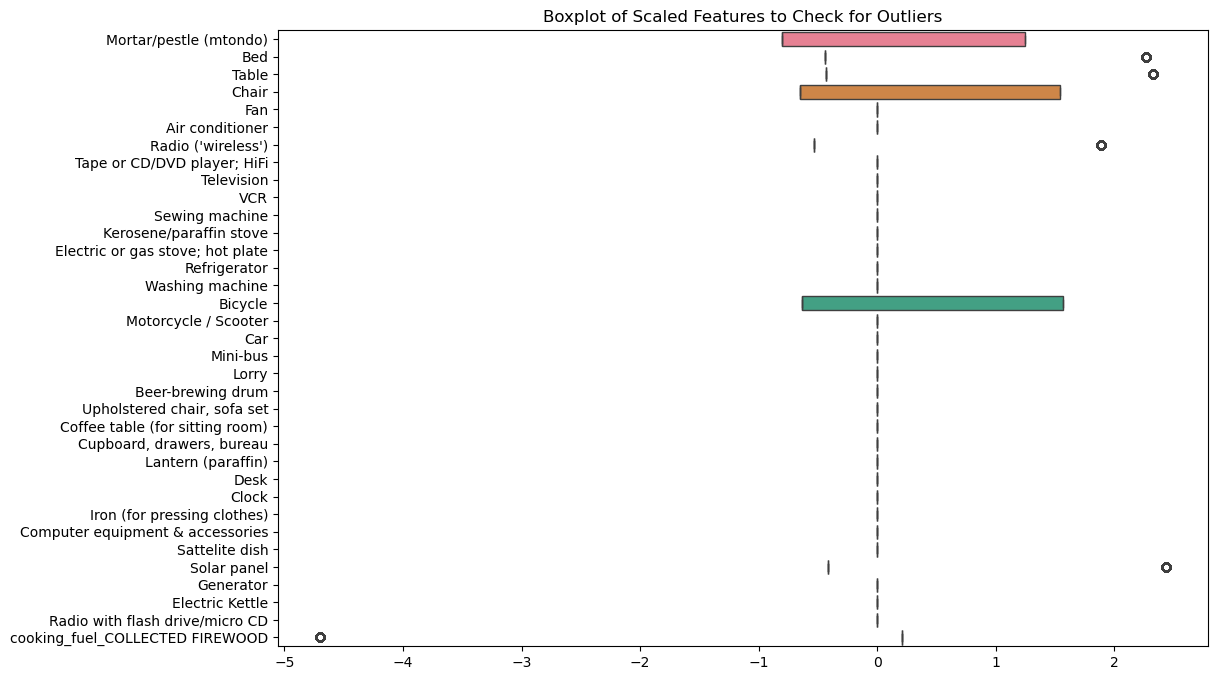

Explained variance ratio of the first component: [0.23236515]


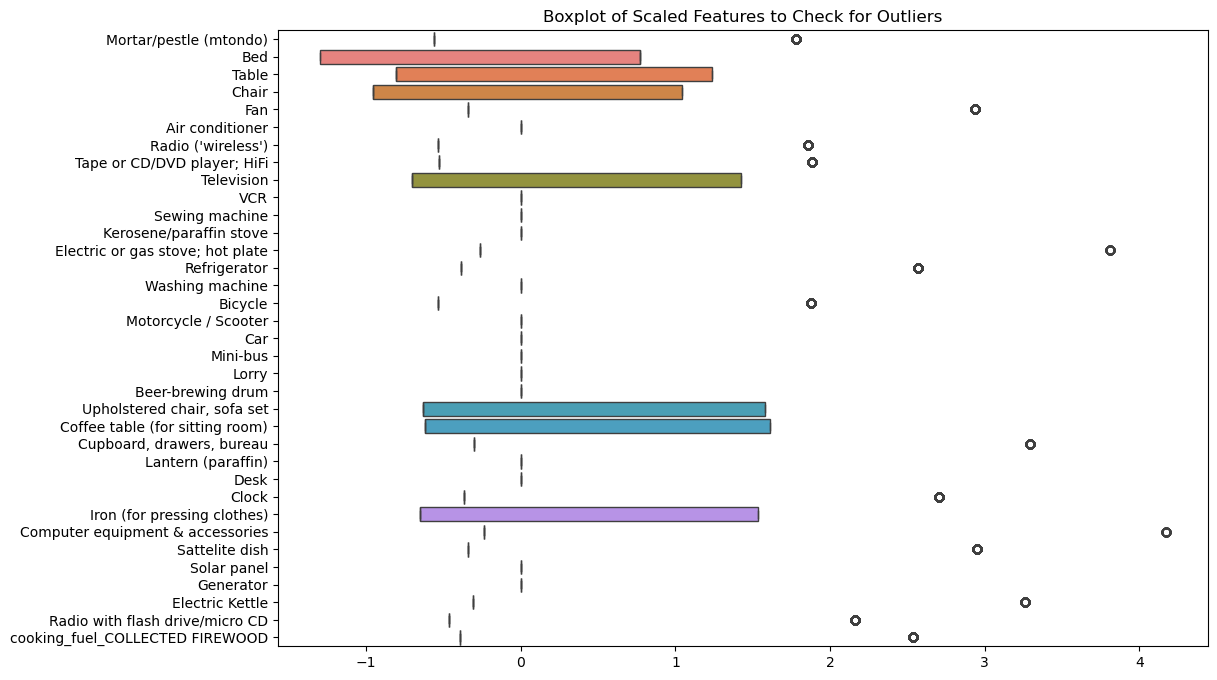

Explained variance ratio of the first component: [0.25279624]


,case_id,Air conditioner,Bed,Beer-brewing drum,Bicycle,Car,Chair,Clock,Coffee table (for sitting room),Computer equipment & accessories,...,"Upholstered chair, sofa set",VCR,Washing machine,cooking_fuel,region,reside,hh_wgt,Type of place of residence,wealth_index,Wealth index factor score for urban/rural (5 decimals)
0,101011000014,0,1,0,0,0,1,0,0,0,...,0,0,0,COLLECTED FIREWOOD,North,rural,93.719400,2,2.298519,229852
1,101011000023,0,0,0,1,0,0,0,0,0,...,0,0,0,COLLECTED FIREWOOD,North,rural,93.719400,2,0.841763,84176
2,101011000040,0,0,0,0,0,0,0,0,0,...,0,0,0,COLLECTED FIREWOOD,North,rural,93.719400,2,-0.610654,-61065
5,101011000115,0,0,0,0,0,1,0,0,0,...,0,0,0,COLLECTED FIREWOOD,North,rural,93.719400,2,-0.112764,-11276
6,101011000126,0,1,0,1,0,0,0,0,0,...,0,0,0,COLLECTED FIREWOOD,North,rural,93.719400,2,1.203129,120313
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11429,315538160177,0,0,0,0,0,0,0,0,0,...,0,0,0,CHARCOAL,Southern,urban,607.988356,1,-2.092753,-209275
11430,315538160189,0,0,0,0,0,0,0,0,0,...,0,0,0,CHARCOAL,Southern,urban,607.988356,1,-0.745520,-74552
11431,315538160190,0,1,0,0,0,1,0,1,0,...,1,0,0,CHARCOAL,Southern,urban,607.988356,1,5.597638,559764
11432,315538160235,0,1,0,0,0,0,1,0,0,...,0,0,0,CHARCOAL,Southern,urban,607.988356,1,2.417153,241715


In [93]:
binary_vars = goods_list
categorical_vars = ['cooking_fuel']#, 'floor_type']

# Calculate wealth index for urban/rural
wealth_df = calculate_wealth_index_extended(df_pc, binary_vars, categorical_vars, 'reside')
wealth_df['Wealth index factor score for urban/rural (5 decimals)'] = (wealth_df['wealth_index'] * 100000).round(0).astype(int)
wealth_df

In [94]:
df_merged


,case_id,hh_f11,hh_f11_oth,hh_f12,hh_f19,hh_f25,hh_f26a,hh_f26b,ea_lat_mod,ea_lon_mod,...,Iron,Radio,Refrigerator,Television,Washing machine,Electricity,region,reside,hh_wgt,Number of household members
0,101011000014,BATTERY/DRY CELL(TORCH),NaN,COLLECTED FIREWOOD,NO,NaN,NaN,NaN,-9.70057,33.239170,...,0.0,0.0,0.0,0.0,0.0,0,North,RURAL,93.719400,4
1,101011000023,BATTERY/DRY CELL(TORCH),NaN,COLLECTED FIREWOOD,NO,NaN,NaN,NaN,-9.70057,33.239170,...,0.0,0.0,0.0,0.0,0.0,0,North,RURAL,93.719400,4
2,101011000040,BATTERY/DRY CELL(TORCH),NaN,COLLECTED FIREWOOD,NO,NaN,NaN,NaN,-9.70057,33.239170,...,0.0,1.0,0.0,0.0,0.0,0,North,RURAL,93.719400,4
3,101011000071,BATTERY/DRY CELL(TORCH),NaN,COLLECTED FIREWOOD,NO,NaN,NaN,NaN,-9.70057,33.239170,...,0.0,1.0,0.0,0.0,0.0,0,North,RURAL,93.719400,5
4,101011000095,BATTERY/DRY CELL(TORCH),NaN,COLLECTED FIREWOOD,NO,NaN,NaN,NaN,-9.70057,33.239170,...,0.0,0.0,0.0,0.0,0.0,0,North,RURAL,93.719400,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11429,315538160177,OTHER(SPECIFY),SOLAR,CHARCOAL,NO,NaN,NaN,NaN,-15.83674,35.036121,...,0.0,1.0,0.0,0.0,0.0,0,Southern,URBAN,607.988356,3
11430,315538160189,ELECTRICITY,NaN,CHARCOAL,YES,5000.0,1.0,MONTH,-15.83674,35.036121,...,0.0,1.0,0.0,1.0,0.0,1,Southern,URBAN,607.988356,3
11431,315538160190,ELECTRICITY,NaN,CHARCOAL,YES,NaN,NaN,NaN,-15.83674,35.036121,...,1.0,1.0,1.0,1.0,0.0,1,Southern,URBAN,607.988356,1
11432,315538160235,ELECTRICITY,NaN,CHARCOAL,YES,4000.0,1.0,MONTH,-15.83674,35.036121,...,0.0,3.0,0.0,1.0,0.0,1,Southern,URBAN,607.988356,3


In [95]:
colum_list = ['case_id', 'Wealth index factor score for urban/rural (5 decimals)', 'Type of place of residence']

# rows with wealth index values
wi_rows = wealth_df['case_id'].unique()

# Filter the columns
df_final = pd.merge(df_merged, wealth_df[colum_list],  on='case_id', how='left')

# Filter the rows with wealth index values
df_final = df_final[df_final['case_id'].isin(wi_rows)]
df_final['reside'] = df_final['reside'].str.lower()
df_final

,case_id,hh_f11,hh_f11_oth,hh_f12,hh_f19,hh_f25,hh_f26a,hh_f26b,ea_lat_mod,ea_lon_mod,...,Refrigerator,Television,Washing machine,Electricity,region,reside,hh_wgt,Number of household members,Wealth index factor score for urban/rural (5 decimals),Type of place of residence
0,101011000014,BATTERY/DRY CELL(TORCH),NaN,COLLECTED FIREWOOD,NO,NaN,NaN,NaN,-9.70057,33.239170,...,0.0,0.0,0.0,0,North,rural,93.719400,4,229852.0,2.0
1,101011000023,BATTERY/DRY CELL(TORCH),NaN,COLLECTED FIREWOOD,NO,NaN,NaN,NaN,-9.70057,33.239170,...,0.0,0.0,0.0,0,North,rural,93.719400,4,84176.0,2.0
2,101011000040,BATTERY/DRY CELL(TORCH),NaN,COLLECTED FIREWOOD,NO,NaN,NaN,NaN,-9.70057,33.239170,...,0.0,0.0,0.0,0,North,rural,93.719400,4,-61065.0,2.0
5,101011000115,BATTERY/DRY CELL(TORCH),NaN,COLLECTED FIREWOOD,NO,NaN,NaN,NaN,-9.70057,33.239170,...,0.0,0.0,0.0,0,North,rural,93.719400,2,-11276.0,2.0
6,101011000126,BATTERY/DRY CELL(TORCH),NaN,COLLECTED FIREWOOD,NO,NaN,NaN,NaN,-9.70057,33.239170,...,0.0,0.0,0.0,0,North,rural,93.719400,3,120313.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11429,315538160177,OTHER(SPECIFY),SOLAR,CHARCOAL,NO,NaN,NaN,NaN,-15.83674,35.036121,...,0.0,0.0,0.0,0,Southern,urban,607.988356,3,-209275.0,1.0
11430,315538160189,ELECTRICITY,NaN,CHARCOAL,YES,5000.0,1.0,MONTH,-15.83674,35.036121,...,0.0,1.0,0.0,1,Southern,urban,607.988356,3,-74552.0,1.0
11431,315538160190,ELECTRICITY,NaN,CHARCOAL,YES,NaN,NaN,NaN,-15.83674,35.036121,...,1.0,1.0,0.0,1,Southern,urban,607.988356,1,559764.0,1.0
11432,315538160235,ELECTRICITY,NaN,CHARCOAL,YES,4000.0,1.0,MONTH,-15.83674,35.036121,...,0.0,1.0,0.0,1,Southern,urban,607.988356,3,241715.0,1.0


# Create **Approximate** Weights-househols  

- Some data sets have the household sampling weight store a float or integer

In [98]:
hh_weight = True #  household weight

if hh_weight == False:
    # census counts from excel file Census_MWI.xlsx

    census_counts = {
        'rural': 3335010,  # total urban households in the country
        'urban': 649976   # total rural households
    }

    # Sample Sizes Per Stratum
    sample_sizes = df_final['reside'].value_counts().to_dict()
    print(sample_sizes)

    # Create a new column with the approximate weight for each row
    df_final['weight'] = df_final['reside'].apply(lambda x: census_counts[x] / sample_sizes[x])
    df_final['Household sample weight (6 decimals)'] = (df_final['weight'] * 1000).round().astype(int) # 3 decimals place/check should be 6
    print(df_final.head(5))
else:
    #df_final = df_final.rename(columns={'hh_wgt':'Household sample weight (6 decimals)'})
    # household weight from the data set
    df_final['Household sample weight (6 decimals)'] = (df_final['hh_wgt'] * 1000000).round().astype(int)



In [99]:
df_final

,case_id,hh_f11,hh_f11_oth,hh_f12,hh_f19,hh_f25,hh_f26a,hh_f26b,ea_lat_mod,ea_lon_mod,...,Television,Washing machine,Electricity,region,reside,hh_wgt,Number of household members,Wealth index factor score for urban/rural (5 decimals),Type of place of residence,Household sample weight (6 decimals)
0,101011000014,BATTERY/DRY CELL(TORCH),NaN,COLLECTED FIREWOOD,NO,NaN,NaN,NaN,-9.70057,33.239170,...,0.0,0.0,0,North,rural,93.719400,4,229852.0,2.0,93719400
1,101011000023,BATTERY/DRY CELL(TORCH),NaN,COLLECTED FIREWOOD,NO,NaN,NaN,NaN,-9.70057,33.239170,...,0.0,0.0,0,North,rural,93.719400,4,84176.0,2.0,93719400
2,101011000040,BATTERY/DRY CELL(TORCH),NaN,COLLECTED FIREWOOD,NO,NaN,NaN,NaN,-9.70057,33.239170,...,0.0,0.0,0,North,rural,93.719400,4,-61065.0,2.0,93719400
5,101011000115,BATTERY/DRY CELL(TORCH),NaN,COLLECTED FIREWOOD,NO,NaN,NaN,NaN,-9.70057,33.239170,...,0.0,0.0,0,North,rural,93.719400,2,-11276.0,2.0,93719400
6,101011000126,BATTERY/DRY CELL(TORCH),NaN,COLLECTED FIREWOOD,NO,NaN,NaN,NaN,-9.70057,33.239170,...,0.0,0.0,0,North,rural,93.719400,3,120313.0,2.0,93719400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11429,315538160177,OTHER(SPECIFY),SOLAR,CHARCOAL,NO,NaN,NaN,NaN,-15.83674,35.036121,...,0.0,0.0,0,Southern,urban,607.988356,3,-209275.0,1.0,607988356
11430,315538160189,ELECTRICITY,NaN,CHARCOAL,YES,5000.0,1.0,MONTH,-15.83674,35.036121,...,1.0,0.0,1,Southern,urban,607.988356,3,-74552.0,1.0,607988356
11431,315538160190,ELECTRICITY,NaN,CHARCOAL,YES,NaN,NaN,NaN,-15.83674,35.036121,...,1.0,0.0,1,Southern,urban,607.988356,1,559764.0,1.0,607988356
11432,315538160235,ELECTRICITY,NaN,CHARCOAL,YES,4000.0,1.0,MONTH,-15.83674,35.036121,...,1.0,0.0,1,Southern,urban,607.988356,3,241715.0,1.0,607988356


In [100]:
# df with household data
df_final.to_csv('../Data/IHS_survey/household_data_IHS.csv', index=False)

In [101]:
# df with only the case_id households used for the analysis
df_final['case_id'].to_csv('../Data/IHS_survey/household_data_IHS_case_id.csv', index=False)
